First 5 rows:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M     1.097064     -2.073335        1.269934   0.984375   
1         M     1.829821     -0.353632        1.685955   1.908708   
2         M     1.579888      0.456187        1.566503   1.558884   
3         M    -0.768909      0.253732       -0.592687  -0.764464   
4         M     1.750297     -1.151816        1.776573   1.826229   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         1.568466          3.283515        2.652874             2.532475   
1        -0.826962         -0.487072       -0.023846             0.548144   
2         0.942210          1.052926        1.363478             2.037231   
3         3.283553          3.402909        1.915897             1.451707   
4         0.280372          0.539340        1.371011             1.428493   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0       2.217515  ...      1.886690  

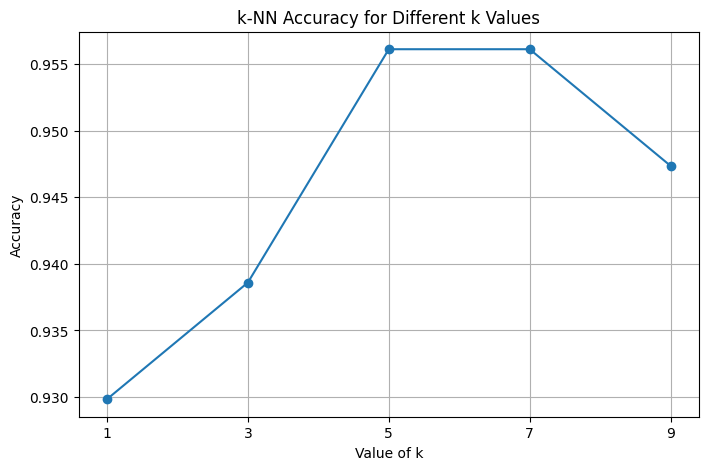


Best k value: 5
Best Accuracy: 0.9561

Final Model Accuracy:
0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



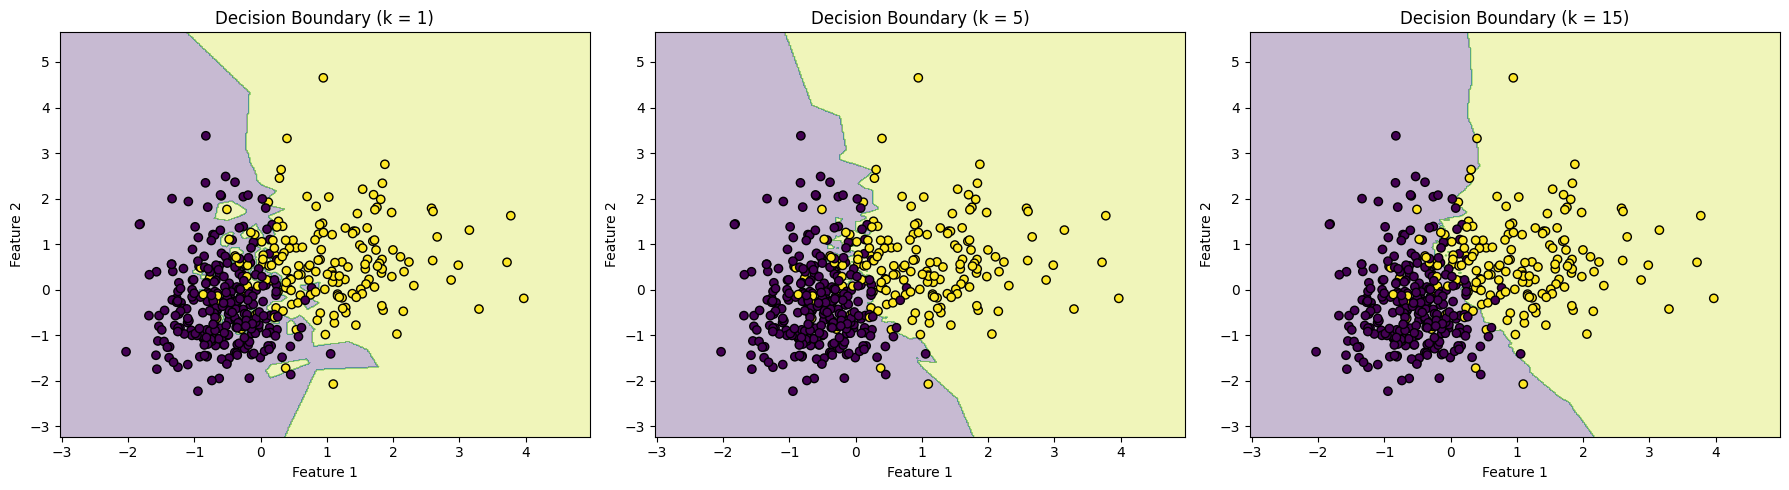


Conclusion:
Missing values were identified and handled using median imputation.
The k-NN classifier was trained for different values of k.
The effect of k on classification accuracy was analyzed.
Decision boundaries were plotted for different k values.


In [2]:
# ---------------------------------------------------------
# MACHINE LEARNING - CO2
# Program 1: k-Nearest Neighbour Classification
# Dataset: breast_cancer.csv
# ---------------------------------------------------------

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------

df = pd.read_csv("breast_cancer.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ---------------------------------------------------------
# 2. Dataset Information
# ---------------------------------------------------------

print("\nDataset Information:")
df.info()


# ---------------------------------------------------------
# 3. Check Missing Values
# ---------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ---------------------------------------------------------
# 4. Remove Unnecessary ID Column
# ---------------------------------------------------------

# Remove common ID columns if present
id_columns = ["id", "ID", "Id"]

for col in id_columns:
    if col in df.columns:
        df = df.drop(columns=[col])


# ---------------------------------------------------------
# 5. Identify Target Column
# ---------------------------------------------------------

# Try common target column names
possible_targets = [
    "diagnosis",
    "Diagnosis",
    "target",
    "Target",
    "class",
    "Class",
    "label",
    "Label"
]

target_column = None

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

# If no common target name is found,
# assume the last column is the target
if target_column is None:
    target_column = df.columns[-1]

print("\nTarget Column:")
print(target_column)


# ---------------------------------------------------------
# 6. Separate Features and Target
# ---------------------------------------------------------

X = df.drop(columns=[target_column])
y = df[target_column]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.unique())


# ---------------------------------------------------------
# 7. Convert Categorical Target into Numbers
# ---------------------------------------------------------

if y.dtype == "object":
    y = y.astype("category").cat.codes

print("\nEncoded Target:")
print(y.unique())


# ---------------------------------------------------------
# 8. Keep Only Numeric Features
# ---------------------------------------------------------

X = X.select_dtypes(include=np.number)

print("\nNumeric Features:")
print(X.columns.tolist())


# ---------------------------------------------------------
# 9. Handle Missing Values
# ---------------------------------------------------------

print("\nMissing Values Before Imputation:")
print(X.isnull().sum())

# Replace missing values with the median
imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(X)

print("\nMissing values handled using median imputation.")


# ---------------------------------------------------------
# 10. Split Dataset into Training and Testing Sets
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


# ---------------------------------------------------------
# 11. Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------------------------------------------------
# 12. Train k-NN for Different k Values
# ---------------------------------------------------------

k_values = [1, 3, 5, 7, 9]

accuracies = []

print("\nAccuracy for Different k Values:")

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print("k =", k, "Accuracy =", round(accuracy, 4))


# ---------------------------------------------------------
# 13. Plot Accuracy vs k
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy for Different k Values")

plt.xticks(k_values)
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 14. Select Best k
# ---------------------------------------------------------

best_index = np.argmax(accuracies)
best_k = k_values[best_index]

print("\nBest k value:", best_k)
print("Best Accuracy:", round(accuracies[best_index], 4))


# ---------------------------------------------------------
# 15. Train Final k-NN Model
# ---------------------------------------------------------

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train, y_train)

final_prediction = final_knn.predict(X_test)


# ---------------------------------------------------------
# 16. Final Model Performance
# ---------------------------------------------------------

print("\nFinal Model Accuracy:")
print(accuracy_score(y_test, final_prediction))

print("\nClassification Report:")
print(classification_report(y_test, final_prediction))


# ---------------------------------------------------------
# 17. Decision Boundary
# ---------------------------------------------------------

# For visualization, use only the first two numerical features

X_visual = df.select_dtypes(include=np.number).drop(
    columns=[],
    errors="ignore"
)

X_visual = X_visual.iloc[:, :2]

# Handle missing values
X_visual = SimpleImputer(strategy="median").fit_transform(X_visual)

# Scale features
visual_scaler = StandardScaler()
X_visual = visual_scaler.fit_transform(X_visual)

# Split data
Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_visual,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# 18. Plot Decision Boundaries for Different k Values
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

boundary_k_values = [1, 5, 15]

for ax, k in zip(axes, boundary_k_values):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(Xv_train, yv_train)

    # Create mesh grid
    x_min = Xv_train[:, 0].min() - 1
    x_max = Xv_train[:, 0].max() + 1

    y_min = Xv_train[:, 1].min() - 1
    y_max = Xv_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict each point in the mesh
    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Draw decision boundary
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    # Draw training samples
    ax.scatter(
        Xv_train[:, 0],
        Xv_train[:, 1],
        c=yv_train,
        edgecolor="black"
    )

    ax.set_title("Decision Boundary (k = " + str(k) + ")")
    ax.set_xlabel(X_visual.columns[0] if hasattr(X_visual, "columns") else "Feature 1")
    ax.set_ylabel(X_visual.columns[1] if hasattr(X_visual, "columns") else "Feature 2")


plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 19. Conclusion
# ---------------------------------------------------------

print("\nConclusion:")
print("Missing values were identified and handled using median imputation.")
print("The k-NN classifier was trained for different values of k.")
print("The effect of k on classification accuracy was analyzed.")
print("Decision boundaries were plotted for different k values.")